# Sigap.ai - Logistic Regression Baseline for Sentiment Analysis

Notebook ini disusun untuk proyek capstone IBM SkillsBuild Sigap.ai sebagai baseline yang dapat langsung dijalankan di Google Colab.

Scope notebook ini dibatasi secara tegas pada data yang sudah final:
- proses data collection sudah selesai
- proses cleaning sudah selesai
- proses labeling sudah selesai
- proses balancing sudah selesai
- proses splitting sudah selesai
- proses preprocessing sudah selesai

Eksperimen ini hanya menggunakan:
- feature: `Review_Text_Processed`
- target: `Sentiment_Label`

Notebook mencakup:
- loading data train/validation/test
- label encoding
- TF-IDF feature engineering
- baseline Logistic Regression
- hyperparameter tuning
- final model training
- evaluasi validation dan test
- visualisasi profesional
- error analysis
- explainable AI
- business analysis
- penyimpanan model dan ekspor hasil

## SECTION 1 - Project Overview

### Tujuan eksperimen
Tujuan eksperimen ini adalah membangun baseline klasifikasi sentimen yang kuat, interpretabel, dan mudah direplikasi untuk dataset review UMKM Indonesia pada proyek Sigap.ai. Fokus utama notebook ini bukan membangun model paling kompleks, tetapi menghasilkan benchmark yang kredibel untuk membandingkan metode lanjutan pada eksperimen berikutnya.

### Alasan menggunakan Logistic Regression sebagai baseline
Logistic Regression merupakan baseline yang tepat untuk problem klasifikasi teks dengan TF-IDF karena:
- bekerja sangat baik pada data sparse berdimensi tinggi
- cepat dilatih dan cepat dievaluasi
- stabil untuk multi-class classification
- mudah diinterpretasikan melalui koefisien fitur
- menjadi pembanding yang solid sebelum mencoba model neural network atau transformer

Dalam konteks capstone, baseline ini juga penting untuk menunjukkan bahwa performa model berasal dari proses yang terukur, bukan dari kompleksitas model semata.

## SECTION 2 - Import Library

Library yang digunakan dibatasi pada stack yang umum dipakai untuk eksperimen machine learning terstruktur:
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Scikit-Learn
- Joblib

In [1]:
import os
from pathlib import Path

import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, validation_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11
pd.set_option('display.max_colwidth', 250)
pd.set_option('display.max_columns', 100)

## SECTION 3 - Load Dataset

Notebook ini mencoba menemukan file dataset secara otomatis agar tetap fleksibel saat dijalankan di Google Colab maupun pada workspace lokal.

Jika nama file Anda adalah `df_train_final.csv`, `df_validation_final.csv`, dan `df_test_final.csv`, notebook akan tetap mencarinya. Jika file yang tersedia adalah `train_final.csv`, `validation_final.csv`, dan `test_final.csv`, notebook juga akan menggunakannya.

In [2]:
PROJECT_ROOT = Path.cwd()

TRAIN_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "train_final.csv"
VAL_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "validation_final.csv"
TEST_PATH = PROJECT_ROOT / "dataset" / "processed-dataset" / "test_final.csv"

print(TRAIN_PATH)
print(VAL_PATH)
print(TEST_PATH)

df_train = pd.read_csv(TRAIN_PATH)
df_val = pd.read_csv(VAL_PATH)
df_test = pd.read_csv(TEST_PATH)

print("\nDataset Loaded Successfully")
print("Train      :", df_train.shape)
print("Validation :", df_val.shape)
print("Test       :", df_test.shape)

print("\nColumns:")
print(df_train.columns.tolist())

/Users/egipsinargo/Downloads/sigap-ai/ai/dataset/processed-dataset/train_final.csv
/Users/egipsinargo/Downloads/sigap-ai/ai/dataset/processed-dataset/validation_final.csv
/Users/egipsinargo/Downloads/sigap-ai/ai/dataset/processed-dataset/test_final.csv

Dataset Loaded Successfully
Train      : (37197, 9)
Validation : (7973, 9)
Test       : (7986, 9)

Columns:
['Review_Text', 'Review_Text_Processed', 'Review_Date', 'Rating_Score', 'Business_Category', 'Sentiment_Label', 'Review_Aspect', 'Crisis_Flag', 'Is_Sarcasm']


In [3]:
expected_columns = [
    'Review_Text',
    'Review_Text_Processed',
    'Review_Date',
    'Rating_Score',
    'Business_Category',
    'Sentiment_Label',
    'Review_Aspect',
    'Crisis_Flag',
    'Is_Sarcasm'
]

for split_name, df in [
    ('Train', df_train),
    ('Validation', df_val),
    ('Test', df_test)
]:
    missing = [c for c in expected_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f'{split_name} missing columns: {missing}'
        )

    print(f'\n{split_name} shape: {df.shape}')
    print('Label distribution:')
    display(df['Sentiment_Label'].value_counts().to_frame('count'))

    print('Sample data:')
    display(
        df[
            ['Review_Text_Processed', 'Sentiment_Label']
        ].head(5)
    )

train_df = df_train.copy()
val_df = df_val.copy()
test_df = df_test.copy()

print("\nDataset validation passed")


Train shape: (37197, 9)
Label distribution:


,count
Sentiment_Label,
Negative,12431
Netral,12424
Positive,12342


Sample data:


,Review_Text_Processed,Sentiment_Label
0,mangstab top markotop sip markosip bagus markojos,Positive
1,nice suasana but far too less items as options for food in the makan malam buffet would suggest the management to improve the spread as we hardly get couple of options cuisine in this multi cuisine spread that hyatt offers,Netral
2,there was lot of disturbance but running area layan was good but ambiance was not good money is sortable biryani was not so good irani chai is good,Netral
3,tolong tambah fitur cetak pesan struk singkat waktu layan nulis nota manual lumayan kalo pesan notifikasi jarang muncul,Negative
4,luas cocok istirahat sore jelang malam,Positive



Validation shape: (7973, 9)
Label distribution:


...


Test shape: (7986, 9)
Label distribution:


,count
Sentiment_Label,
Netral,2664
Negative,2662
Positive,2660


Sample data:


,Review_Text_Processed,Sentiment_Label
0,parah go gek masak order go food diemin hari saldo blum rekening ulang komplain admin msih lambat masuk saldo rekening uang hasil jual pakai modal bahan baku masakan resto evaluasi kerja sistem kerja adminya go food terima kasih,Negative
1,tidak ngotak harga makan lapak rebu app grab blum ongkir parah banget sumpah,Netral
2,bagaimna daftar makan,Netral
3,layan mas rokhmatullah menu makan suasana teduh,Positive
4,efisien aplikasiny praktis tahap2 oh saran pake debit cc,Netral



Dataset validation passed


## SECTION 4 - Label Encoding

Target label pada dataset menggunakan istilah `Netral`, sedangkan eksperimen ini menggunakan standar akademik yang lebih konsisten, yaitu `Neutral`.

Pada tahap ini:
- label distandarkan menjadi `Positive`, `Neutral`, `Negative`
- label kemudian diencode menggunakan `LabelEncoder`
- mapping label disimpan agar interpretasi hasil tetap transparan

In [4]:
def standardize_label(label):
    label = str(label).strip()
    if label.lower() == 'netral':
        return 'Neutral'
    return label

for df in [train_df, val_df, test_df]:
    df['Sentiment_Label'] = df['Sentiment_Label'].apply(standardize_label)

label_order = ['Negative', 'Neutral', 'Positive']
label_encoder = LabelEncoder()
label_encoder.fit(label_order)

label_mapping = {label: int(label_encoder.transform([label])[0]) for label in label_encoder.classes_}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}

print('Label Mapping:')
display(pd.DataFrame({'label': list(label_mapping.keys()), 'encoded_value': list(label_mapping.values())}))

train_y = label_encoder.transform(train_df['Sentiment_Label'])
val_y = label_encoder.transform(val_df['Sentiment_Label'])
test_y = label_encoder.transform(test_df['Sentiment_Label'])

print('Encoded classes:', list(label_encoder.classes_))

Label Mapping:


,label,encoded_value
0,Negative,0
1,Neutral,1
2,Positive,2


Encoded classes: [np.str_('Negative'), np.str_('Neutral'), np.str_('Positive')]


## SECTION 5 - TF-IDF Feature Engineering

Eksperimen TF-IDF dilakukan untuk membandingkan representasi teks yang berbeda sebelum model final dibangun.

Konfigurasi yang diuji:
1. Unigram
2. Unigram + Bigram
3. Tuning `max_features`

Semua eksperimen pada section ini memakai Logistic Regression default sebagai pembanding, lalu dievaluasi pada validation set.

,experiment,ngram_range,max_features,accuracy,precision_macro,recall_macro,f1_macro,vocab_size
0,max_features=20000,"(1, 2)",20000,0.753042,0.750830,0.753389,0.751446,20000
1,Unigram + Bigram,"(1, 2)",10000,0.749028,0.746869,0.749381,0.747446,10000
2,max_features=10000,"(1, 2)",10000,0.749028,0.746869,0.749381,0.747446,10000
3,max_features=5000,"(1, 2)",5000,0.745642,0.743287,0.745997,0.744113,5000
4,Unigram,"(1, 1)",10000,0.738242,0.735157,0.738621,0.736243,10000


/var/folders/l3/7nyr5mt91s39xqf3bp9dlwww0000gn/T/ipykernel_23706/3054660917.py:205: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


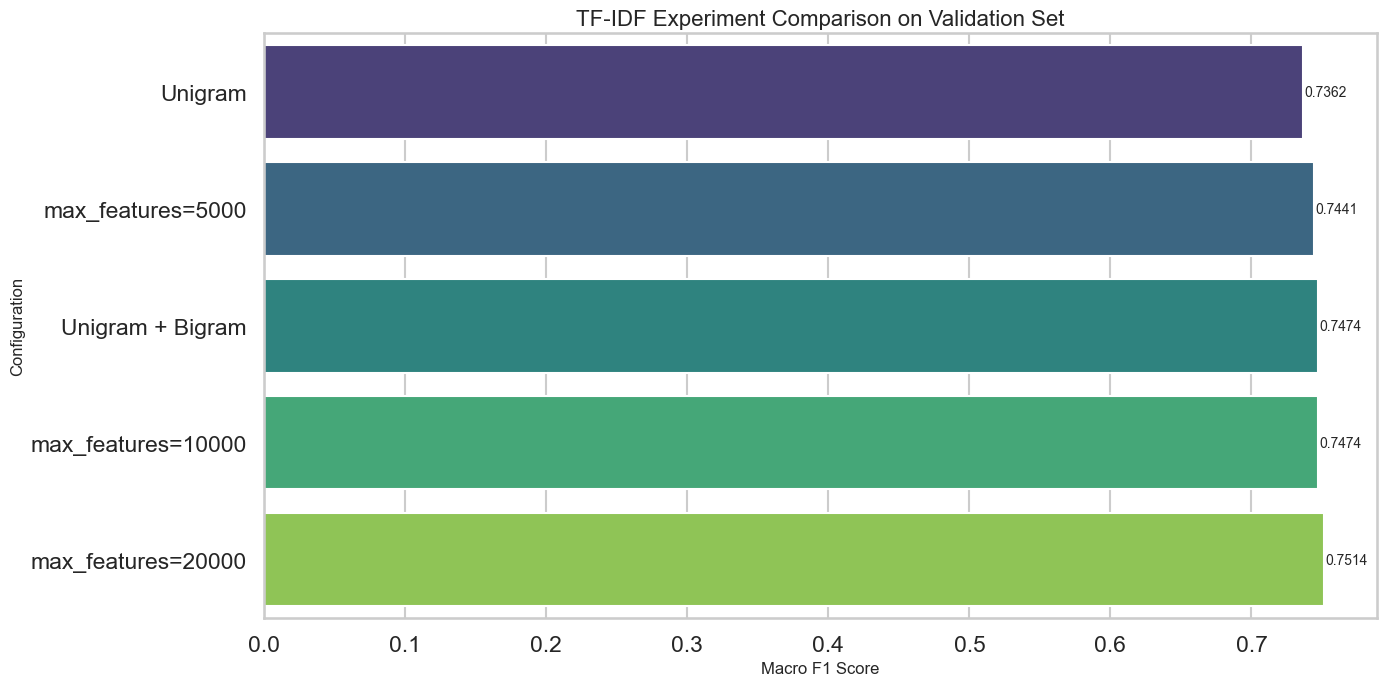


Best TF-IDF Configuration
{'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2, 'max_df': 0.95}

Best Validation F1
0.7514


In [5]:
X_train = train_df['Review_Text_Processed'].fillna('').astype(str)
X_val = val_df['Review_Text_Processed'].fillna('').astype(str)
X_test = test_df['Review_Text_Processed'].fillna('').astype(str)


def build_pipeline(tfidf_params, lr_params=None):
    if lr_params is None:
        lr_params = {}

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        sublinear_tf=True,
        norm='l2',
        **tfidf_params
    )

    classifier = LogisticRegression(
        random_state=42,
        max_iter=1000,
        **lr_params
    )

    return Pipeline([
        ('tfidf', vectorizer),
        ('logreg', classifier)
    ])


def evaluate_pipeline(
    pipeline,
    x_train,
    y_train,
    x_eval,
    y_eval
):
    pipeline.fit(x_train, y_train)

    pred = pipeline.predict(x_eval)
    proba = pipeline.predict_proba(x_eval)

    return {
        'accuracy': accuracy_score(y_eval, pred),
        'precision_macro': precision_score(
            y_eval,
            pred,
            average='macro',
            zero_division=0
        ),
        'recall_macro': recall_score(
            y_eval,
            pred,
            average='macro',
            zero_division=0
        ),
        'f1_macro': f1_score(
            y_eval,
            pred,
            average='macro',
            zero_division=0
        ),
        'pred': pred,
        'proba': proba,
        'pipeline': pipeline
    }


experiment_rows = []

# EXPERIMENT 1
# UNIGRAM VS BIGRAM

base_max_features = 10000

ngram_experiments = [
    (
        'Unigram',
        {
            'ngram_range': (1, 1),
            'max_features': base_max_features,
            'min_df': 2,
            'max_df': 0.95
        }
    ),
    (
        'Unigram + Bigram',
        {
            'ngram_range': (1, 2),
            'max_features': base_max_features,
            'min_df': 2,
            'max_df': 0.95
        }
    )
]

for exp_name, tfidf_params in ngram_experiments:

    pipeline = build_pipeline(tfidf_params)

    result = evaluate_pipeline(
        pipeline,
        X_train,
        train_y,
        X_val,
        val_y
    )

    experiment_rows.append({
        'experiment': exp_name,
        'ngram_range': str(tfidf_params['ngram_range']),
        'max_features': tfidf_params['max_features'],
        'accuracy': result['accuracy'],
        'precision_macro': result['precision_macro'],
        'recall_macro': result['recall_macro'],
        'f1_macro': result['f1_macro'],
        'vocab_size': len(
            result['pipeline']
            .named_steps['tfidf']
            .vocabulary_
        )
    })

experiment_results = pd.DataFrame(experiment_rows)

best_ngram_row = (
    experiment_results
    .sort_values(
        'f1_macro',
        ascending=False
    )
    .iloc[0]
)

best_ngram_range = ast.literal_eval(
    best_ngram_row['ngram_range']
)

# EXPERIMENT 2
# MAX FEATURES

max_features_grid = [
    5000,
    10000,
    20000
]

for mf in max_features_grid:

    tfidf_params = {
        'ngram_range': best_ngram_range,
        'max_features': mf,
        'min_df': 2,
        'max_df': 0.95
    }

    pipeline = build_pipeline(tfidf_params)

    result = evaluate_pipeline(
        pipeline,
        X_train,
        train_y,
        X_val,
        val_y
    )

    experiment_rows.append({
        'experiment': f'max_features={mf}',
        'ngram_range': str(tfidf_params['ngram_range']),
        'max_features': tfidf_params['max_features'],
        'accuracy': result['accuracy'],
        'precision_macro': result['precision_macro'],
        'recall_macro': result['recall_macro'],
        'f1_macro': result['f1_macro'],
        'vocab_size': len(
            result['pipeline']
            .named_steps['tfidf']
            .vocabulary_
        )
    })

# RESULT TABLE

experiment_results = (
    pd.DataFrame(experiment_rows)
    .sort_values(
        'f1_macro',
        ascending=False
    )
    .reset_index(drop=True)
)

display(experiment_results)

# VISUALIZATION

fig, ax = plt.subplots(
    figsize=(14, 7)
)

plot_df = experiment_results.sort_values(
    'f1_macro',
    ascending=True
)

sns.barplot(
    data=plot_df,
    x='f1_macro',
    y='experiment',
    palette='viridis',
    ax=ax
)

ax.set_title(
    'TF-IDF Experiment Comparison on Validation Set'
)

ax.set_xlabel(
    'Macro F1 Score'
)

ax.set_ylabel(
    'Configuration'
)

for i, v in enumerate(plot_df['f1_macro']):
    ax.text(
        v + 0.001,
        i,
        f'{v:.4f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# BEST CONFIGURATION

best_feature_row = experiment_results.iloc[0]

BEST_TFIDF_PARAMS = {
    'ngram_range': ast.literal_eval(
        best_feature_row['ngram_range']
    ),
    'max_features': int(
        best_feature_row['max_features']
    ),
    'min_df': 2,
    'max_df': 0.95
}

print("\nBest TF-IDF Configuration")
print(BEST_TFIDF_PARAMS)

print("\nBest Validation F1")
print(
    round(
        best_feature_row['f1_macro'],
        4
    )
)

## SECTION 6 - Baseline Model

Baseline Logistic Regression dilatih menggunakan konfigurasi TF-IDF terbaik dari Section 5, dengan hyperparameter Logistic Regression tetap default.

Tujuannya adalah mendapatkan baseline yang stabil dan langsung bisa dibandingkan dengan hasil tuning berikutnya.

In [6]:
baseline_model = build_pipeline(BEST_TFIDF_PARAMS)
baseline_model.fit(X_train, train_y)

val_pred_baseline = baseline_model.predict(X_val)

baseline_validation_metrics = {
    'split': 'validation',
    'accuracy': accuracy_score(val_y, val_pred_baseline),
    'precision_macro': precision_score(val_y, val_pred_baseline, average='macro', zero_division=0),
    'recall_macro': recall_score(val_y, val_pred_baseline, average='macro', zero_division=0),
    'f1_macro': f1_score(val_y, val_pred_baseline, average='macro', zero_division=0),
}

baseline_validation_metrics_df = pd.DataFrame([baseline_validation_metrics])
display(baseline_validation_metrics_df)

print('Classification Report - Baseline Validation')
print(classification_report(val_y, val_pred_baseline, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.753042,0.75083,0.753389,0.751446


Classification Report - Baseline Validation
              precision    recall  f1-score   support

    Negative     0.7360    0.6872    0.7108      2666
     Neutral     0.6902    0.6842    0.6872      2663
    Positive     0.8263    0.8888    0.8564      2644

    accuracy                         0.7530      7973
   macro avg     0.7508    0.7534    0.7514      7973
weighted avg     0.7506    0.7530    0.7512      7973



## SECTION 7 - Hyperparameter Tuning

Hyperparameter tuning dilakukan menggunakan GridSearchCV pada training set saja agar validation set tetap berfungsi sebagai evaluasi yang lebih independen.

Grid yang diuji:
- `C = [0.01, 0.1, 1, 10, 100]`
- `solver = ['lbfgs', 'liblinear']`
- `class_weight = [None, 'balanced']`
- `max_iter = [1000, 2000]`

Scoring yang digunakan adalah `f1_macro` karena dataset sentimen multi-class dan membutuhkan evaluasi yang seimbang antar kelas.

Fitting 3 folds for each of 40 candidates, totalling 120 fits


/Users/egipsinargo/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/egipsinargo/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/Users/egipsinargo/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is depreca

Best Parameters:
{'logreg__C': 1, 'logreg__class_weight': 'balanced', 'logreg__max_iter': 1000, 'logreg__solver': 'lbfgs'}
Best CV F1 Macro: 0.7402686706593934


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_logreg__C,param_logreg__solver,param_logreg__class_weight,param_logreg__max_iter
0,1,0.740269,0.001897,0.853277,0.001575,1.00,lbfgs,balanced,2000
1,1,0.740269,0.001897,0.853277,0.001575,1.00,lbfgs,balanced,1000
2,3,0.740153,0.001802,0.854294,0.002761,1.00,lbfgs,None,2000
3,3,0.740153,0.001802,0.854294,0.002761,1.00,lbfgs,None,1000
4,5,0.738241,0.001940,0.827742,0.001527,1.00,liblinear,None,1000
5,5,0.738241,0.001940,0.827742,0.001527,1.00,liblinear,None,2000
6,7,0.738128,0.001828,0.827663,0.001577,1.00,liblinear,balanced,2000
7,7,0.738128,0.001828,0.827663,0.001577,1.00,liblinear,balanced,1000
8,9,0.730038,0.004275,0.926375,0.001525,10.00,liblinear,None,2000
9,9,0.730038,0.004275,0.926375,0.001525,10.00,liblinear,None,1000


/var/folders/l3/7nyr5mt91s39xqf3bp9dlwww0000gn/T/ipykernel_23706/590366012.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_grid.sort_values('mean_test_score', ascending=True), x='mean_test_score', y='config', palette='mako', ax=ax)


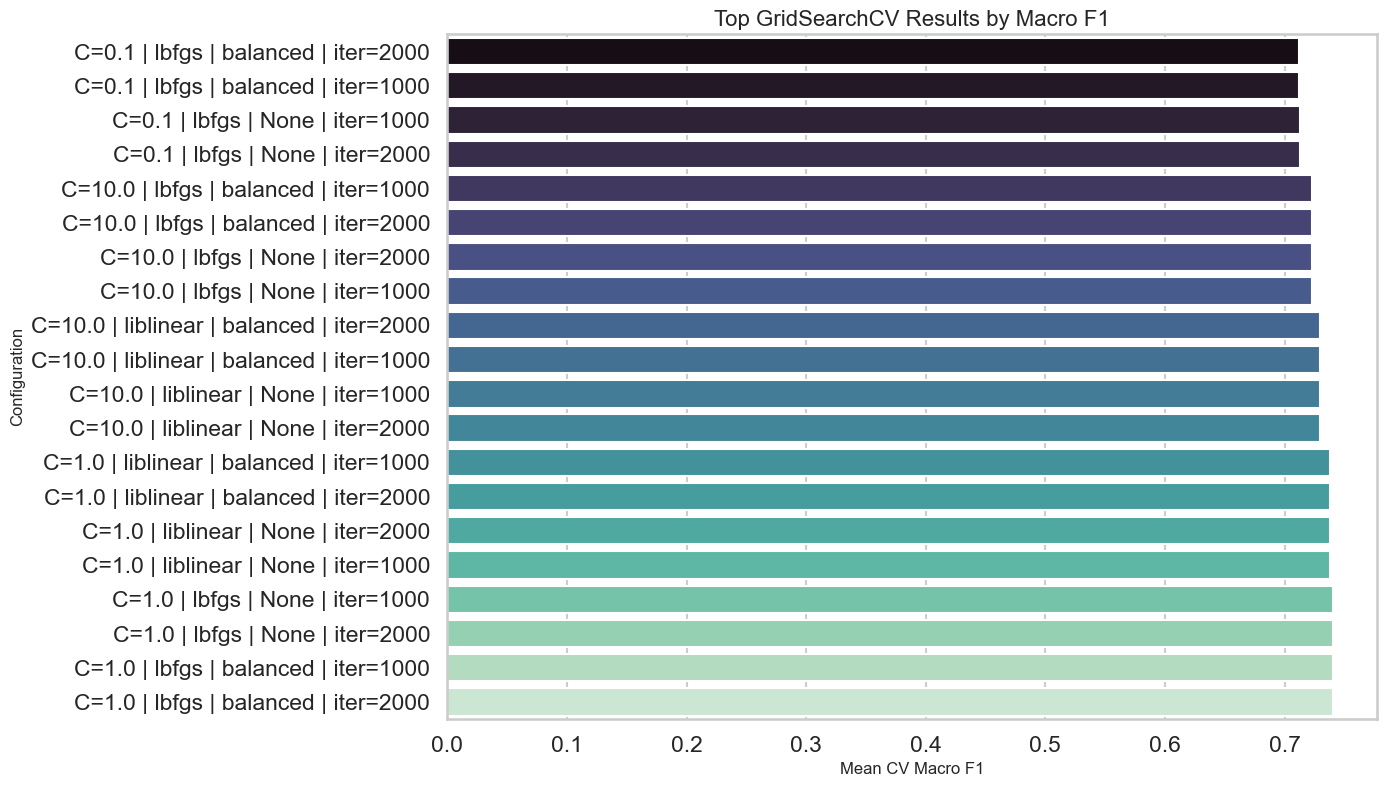

In [7]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

tuning_model = build_pipeline(BEST_TFIDF_PARAMS)
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs', 'liblinear'],
    'logreg__class_weight': [None, 'balanced'],
    'logreg__max_iter': [1000, 2000],
}

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_train, train_y)

print('Best Parameters:')
print(grid_search.best_params_)
print('Best CV F1 Macro:', grid_search.best_score_)

grid_results = pd.DataFrame(grid_search.cv_results_)
cols_to_show = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'std_train_score',
    'param_logreg__C',
    'param_logreg__solver',
    'param_logreg__class_weight',
    'param_logreg__max_iter',
]
grid_results_table = grid_results[cols_to_show].sort_values('rank_test_score').reset_index(drop=True)
display(grid_results_table)

fig, ax = plt.subplots(figsize=(14, 8))
sorted_grid = grid_results_table.head(20).copy()
sorted_grid['config'] = (
    'C=' + sorted_grid['param_logreg__C'].astype(str) +
    ' | ' + sorted_grid['param_logreg__solver'].astype(str) +
    ' | ' + sorted_grid['param_logreg__class_weight'].astype(str) +
    ' | iter=' + sorted_grid['param_logreg__max_iter'].astype(str)
)
sns.barplot(data=sorted_grid.sort_values('mean_test_score', ascending=True), x='mean_test_score', y='config', palette='mako', ax=ax)
ax.set_title('Top GridSearchCV Results by Macro F1')
ax.set_xlabel('Mean CV Macro F1')
ax.set_ylabel('Configuration')
plt.tight_layout()
plt.show()

## SECTION 8 - Final Model Training

Final model dibangun menggunakan parameter terbaik dari GridSearchCV. Model kemudian dilatih kembali pada training set agar seluruh data latih berkontribusi pada parameter final.

In [8]:
final_model = build_pipeline(BEST_TFIDF_PARAMS)
final_model.set_params(**grid_search.best_params_)
final_model.fit(X_train, train_y)

final_vectorizer = final_model.named_steps['tfidf']
final_classifier = final_model.named_steps['logreg']

print('Final model fitted successfully.')
print('Vocabulary size:', len(final_vectorizer.vocabulary_))

Final model fitted successfully.
Vocabulary size: 20000


## SECTION 9 - Evaluation

Evaluasi dilakukan pada validation set dan test set dengan metrik berikut:
- Accuracy
- Precision
- Recall
- F1 Score

Selain metrik agregat, notebook juga menampilkan classification report lengkap untuk masing-masing split.

In [9]:
def evaluate_model(model, x, y, split_name):
    pred = model.predict(x)
    proba = model.predict_proba(x)
    metrics = {
        'split': split_name,
        'accuracy': accuracy_score(y, pred),
        'precision_macro': precision_score(y, pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y, pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y, pred, average='macro', zero_division=0),
    }
    report_dict = classification_report(
        y,
        pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T.reset_index().rename(columns={'index': 'label'})
    return metrics, pred, proba, report_df

val_metrics, val_pred, val_proba, val_report_df = evaluate_model(final_model, X_val, val_y, 'validation')
test_metrics, test_pred, test_proba, test_report_df = evaluate_model(final_model, X_test, test_y, 'test')

metrics_df = pd.DataFrame([val_metrics, test_metrics])
display(metrics_df)
display(val_report_df)
display(test_report_df)

print('Validation Classification Report')
print(classification_report(val_y, val_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

print('Test Classification Report')
print(classification_report(test_y, test_pred, target_names=label_encoder.classes_, digits=4, zero_division=0))

,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.752665,0.750373,0.753016,0.750987
1,test,0.744803,0.742288,0.744857,0.743117


,label,precision,recall,f1-score,support
0,Negative,0.735614,0.685671,0.709765,2666.000000
1,Neutral,0.690819,0.683815,0.687299,2663.000000
2,Positive,0.824684,0.889561,0.855895,2644.000000
3,accuracy,0.752665,0.752665,0.752665,0.752665
4,macro avg,0.750373,0.753016,0.750987,7973.000000
5,weighted avg,0.750190,0.752665,0.750721,7973.000000


,label,precision,recall,f1-score,support
0,Negative,0.724518,0.691585,0.707669,2662.000000
1,Neutral,0.678818,0.664039,0.671347,2664.000000
2,Positive,0.823529,0.878947,0.850336,2660.000000
3,accuracy,0.744803,0.744803,0.744803,0.744803
4,macro avg,0.742288,0.744857,0.743117,7986.000000
5,weighted avg,0.742252,0.744803,0.743073,7986.000000


Validation Classification Report
              precision    recall  f1-score   support

    Negative     0.7356    0.6857    0.7098      2666
     Neutral     0.6908    0.6838    0.6873      2663
    Positive     0.8247    0.8896    0.8559      2644

    accuracy                         0.7527      7973
   macro avg     0.7504    0.7530    0.7510      7973
weighted avg     0.7502    0.7527    0.7507      7973

Test Classification Report
              precision    recall  f1-score   support

    Negative     0.7245    0.6916    0.7077      2662
     Neutral     0.6788    0.6640    0.6713      2664
    Positive     0.8235    0.8789    0.8503      2660

    accuracy                         0.7448      7986
   macro avg     0.7423    0.7449    0.7431      7986
weighted avg     0.7423    0.7448    0.7431      7986



## SECTION 10 - Visualization

Visualisasi dibuat untuk membantu interpretasi performa model secara akademik dan presentatif.

Visualisasi yang disediakan:
1. Confusion Matrix Heatmap
2. ROC Curve multiclass
3. Precision Recall Curve
4. Learning Curve
5. Validation Curve
6. Class Distribution Prediction

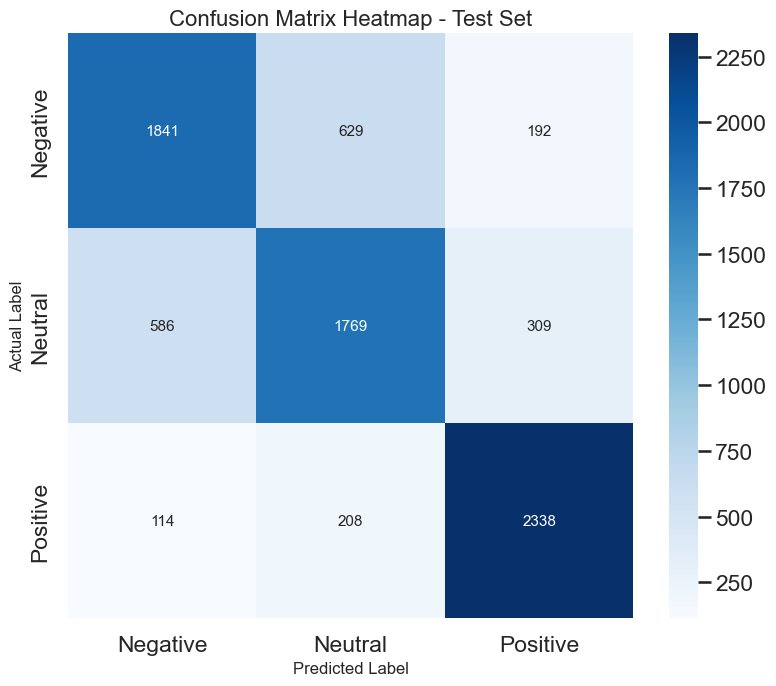

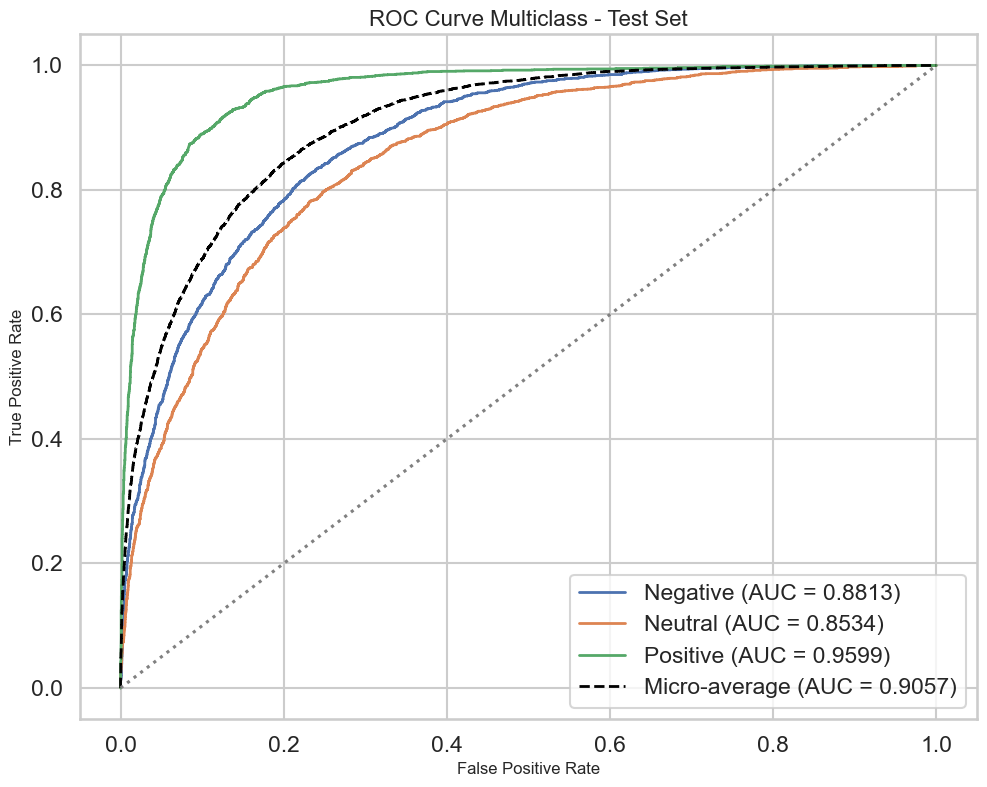

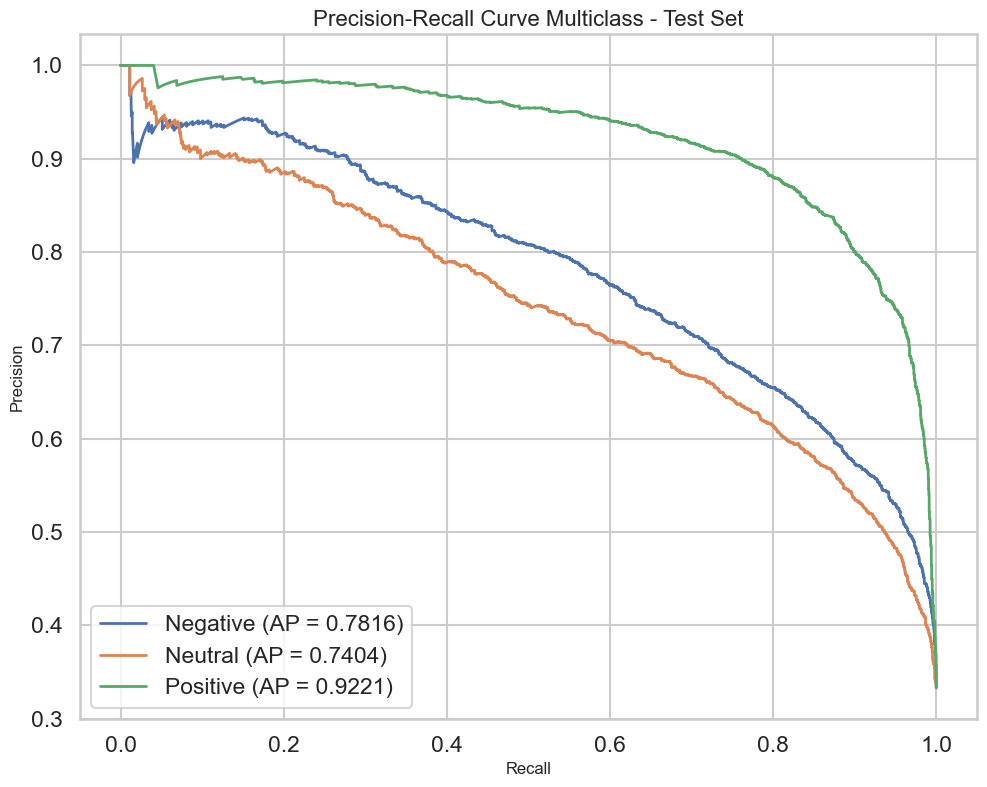

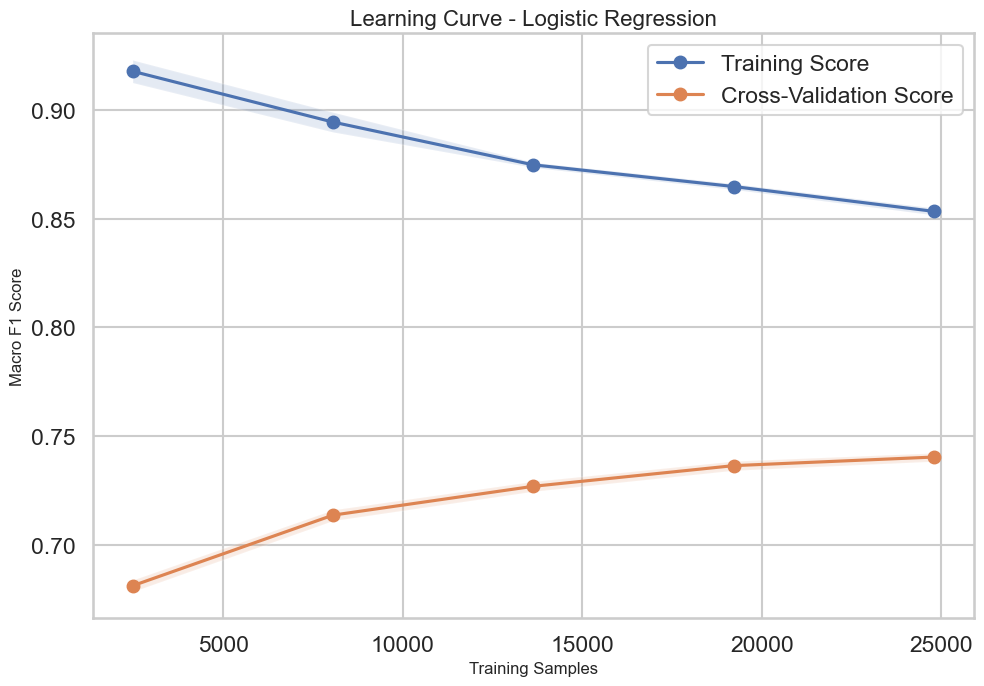

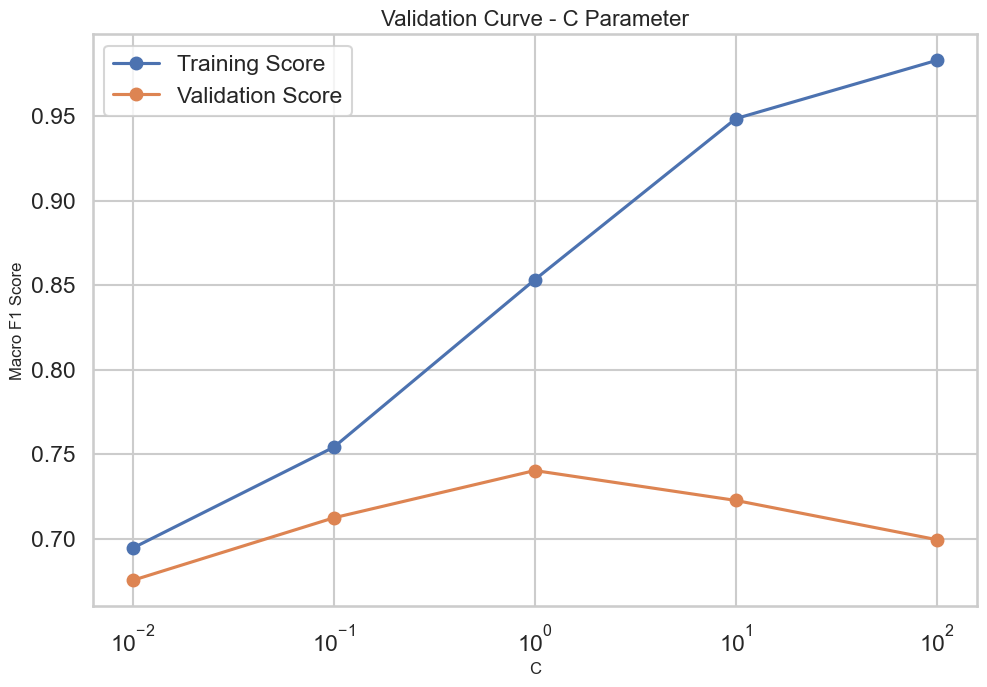

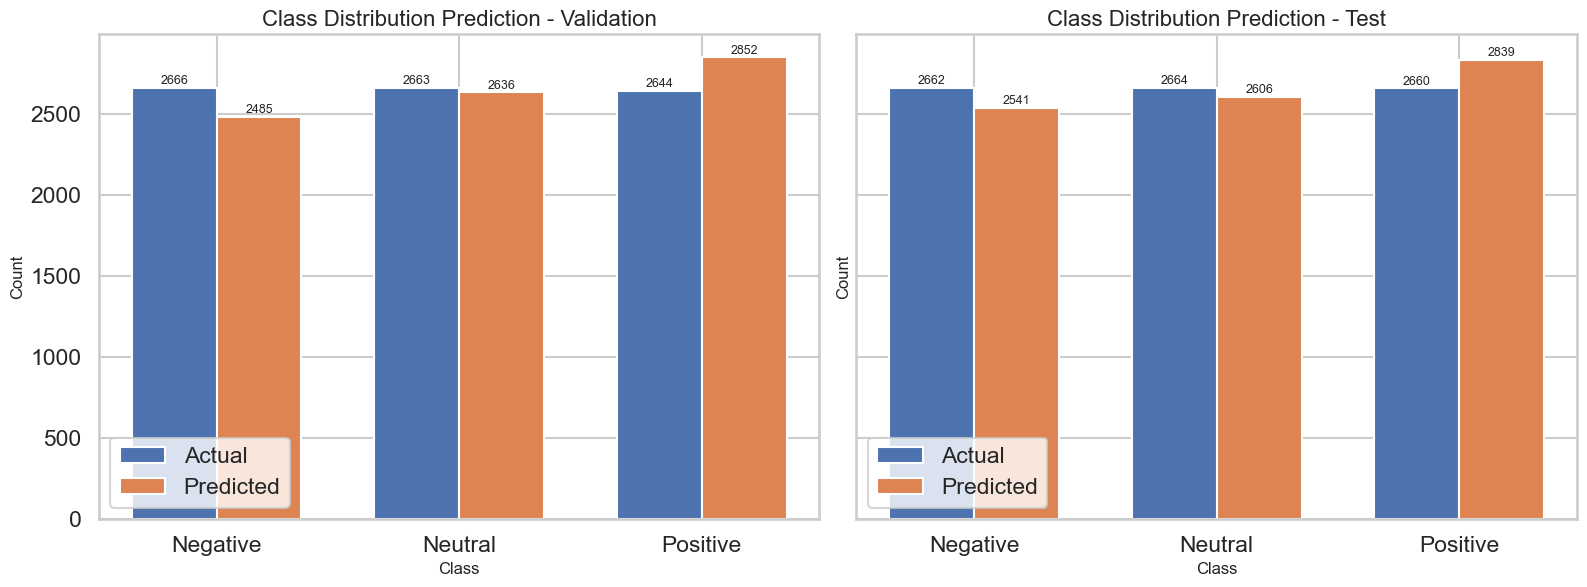

In [10]:
class_names = list(label_encoder.classes_)

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(test_y, test_pred)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix Heatmap - Test Set')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

# 2. ROC Curve Multiclass
fig, ax = plt.subplots(figsize=(10, 8))
y_test_bin = label_binarize(test_y, classes=list(range(len(class_names))))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{cls} (AUC = {roc_auc:.4f})')

fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, linestyle='--', color='black', linewidth=2, label=f'Micro-average (AUC = {roc_auc_micro:.4f})')
ax.plot([0, 1], [0, 1], linestyle=':', color='grey')
ax.set_title('ROC Curve Multiclass - Test Set')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
fig, ax = plt.subplots(figsize=(10, 8))
for i, cls in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], test_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], test_proba[:, i])
    ax.plot(recall, precision, linewidth=2, label=f'{cls} (AP = {ap:.4f})')
ax.set_title('Precision-Recall Curve Multiclass - Test Set')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 4. Learning Curve
train_sizes, train_scores, valid_scores = learning_curve(
    estimator=final_model,
    X=X_train,
    y=train_y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42,
)
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
valid_mean = valid_scores.mean(axis=1)
valid_std = valid_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(train_sizes, train_mean, marker='o', label='Training Score')
ax.plot(train_sizes, valid_mean, marker='o', label='Cross-Validation Score')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.15)
ax.set_title('Learning Curve - Logistic Regression')
ax.set_xlabel('Training Samples')
ax.set_ylabel('Macro F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

# 5. Validation Curve
c_values = np.array([0.01, 0.1, 1, 10, 100])
val_train_scores, val_test_scores = validation_curve(
    estimator=final_model,
    X=X_train,
    y=train_y,
    param_name='logreg__C',
    param_range=c_values,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(c_values, val_train_scores.mean(axis=1), marker='o', label='Training Score')
ax.plot(c_values, val_test_scores.mean(axis=1), marker='o', label='Validation Score')
ax.set_xscale('log')
ax.set_title('Validation Curve - C Parameter')
ax.set_xlabel('C')
ax.set_ylabel('Macro F1 Score')
ax.legend()
plt.tight_layout()
plt.show()

# 6. Class Distribution Prediction
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
actual_pred_tables = {
    'Validation': pd.DataFrame({'Actual': pd.Series(val_y).map(inverse_label_mapping).value_counts(), 'Predicted': pd.Series(val_pred).map(inverse_label_mapping).value_counts()}),
    'Test': pd.DataFrame({'Actual': pd.Series(test_y).map(inverse_label_mapping).value_counts(), 'Predicted': pd.Series(test_pred).map(inverse_label_mapping).value_counts()}),
}

for ax, (split_name, table) in zip(axes, actual_pred_tables.items()):
    plot_table = table.reindex(class_names).fillna(0)
    x = np.arange(len(class_names))
    width = 0.35
    ax.bar(x - width / 2, plot_table['Actual'].values, width=width, label='Actual')
    ax.bar(x + width / 2, plot_table['Predicted'].values, width=width, label='Predicted')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.set_title(f'Class Distribution Prediction - {split_name}')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.legend()
    for i, value in enumerate(plot_table['Actual'].values):
        ax.text(i - width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)
    for i, value in enumerate(plot_table['Predicted'].values):
        ax.text(i + width / 2, value + 5, str(int(value)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## SECTION 11 - Error Analysis

Error analysis difokuskan pada contoh yang salah klasifikasi di test set karena test set adalah representasi paling ketat dari generalisasi model.

Tabel berikut menampilkan 50 contoh salah klasifikasi dengan kolom:
- `Review_Text`
- `Actual_Label`
- `Predicted_Label`

In [11]:
test_predictions_df = pd.DataFrame({
    'Review_Text': test_df['Review_Text'],
    'Review_Text_Processed': test_df['Review_Text_Processed'],
    'Actual_Label': pd.Series(test_y).map(inverse_label_mapping),
    'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping),
    'Crisis_Flag': test_df['Crisis_Flag'].values,
    'Is_Sarcasm': test_df['Is_Sarcasm'].values,
    'Business_Category': test_df['Business_Category'].values,
})

misclassified_df = test_predictions_df[test_predictions_df['Actual_Label'] != test_predictions_df['Predicted_Label']].copy()
error_examples = misclassified_df[['Review_Text', 'Actual_Label', 'Predicted_Label']].head(50)

display(error_examples)

print('Jumlah salah klasifikasi:', len(misclassified_df))
print('Error rate:', round(len(misclassified_df) / len(test_predictions_df) * 100, 2), '%')

print('\nPola kesalahan utama:')
print('- Review pendek atau sangat ringkas lebih sulit dibedakan antar kelas.')
print('- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.')
print('- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.')
print('- Review dengan konteks domain tertentu, terutama yang sangat spesifik, dapat diprediksi kurang stabil jika kosakata latih terbatas.')

confusion_pairs = misclassified_df.groupby(['Actual_Label', 'Predicted_Label']).size().sort_values(ascending=False).to_frame('count')
display(confusion_pairs.head(10))

length_summary = misclassified_df['Review_Text_Processed'].fillna('').astype(str).str.split().str.len().describe().to_frame('misclassified_length')
display(length_summary)

,Review_Text,Actual_Label,Predicted_Label
8,"visited on monday night. had 2 rotis kashmiri and mirchi tandoori roti & dal makhani. overall a good restoran food wise, quantity wise good as well. however was surprised to see no one in the restoran.",Positive,Neutral
10,Sulit untuk mendapat order,Neutral,Negative
15,"respon seller super, pengiriman super, barang super",Negative,Positive
19,"barang sampai dengan bagus gan, cuma sayangnya JNE lelet banget, mesen pake paket YES nyampe nya kayak reguler, over all oke gan",Negative,Positive
23,Tolong grabmerchant diupdate lagi untuk kedua kali y pesanan sy tidak diambil driver dan driver dihubungi tdk ada respon ditambah cara menghubungi cs harus pake pulsa juga ini merugikan resto banget ... Harus y Sistim y seperti yg sebelah berapa ...,Neutral,Negative
29,pesen lv 1 tapi rasanya kayak lv 3. cabe banyak bgttttt 😭 harusnya ga sbanyak ini biasanya kalau lv 1,Negative,Neutral
40,"Orderan Masuk Namun Tidak Menemukan Driver, Sampai 1 Jam Lalu Kena Cancel Oleh Konsumen. Sudah 2 Kali Kejadian 😫",Negative,Neutral
44,"Sudah sampai, packing aman, cuma minus gbsa tracking sndiri ya perjalanan brg, produk baik, smg awet👍🏻",Negative,Positive
50,TOLONG DONG DI SELEKSI LAGI TERIMA DRIVERNYA. kita mitra selalu di persulit sma para driver yg ga kompeten krja nya.,Negative,Neutral
53,"yo ok, memang berbeda dgn resifer yg lama.. ini ga kedip².. ok, remot jg berfungsi langsung ke tv..",Positive,Negative


Jumlah salah klasifikasi: 2038
Error rate: 25.52 %

Pola kesalahan utama:
- Review pendek atau sangat ringkas lebih sulit dibedakan antar kelas.
- Ulasan netral sering tertukar dengan positif atau negatif jika mengandung kata evaluatif yang ambigu.
- Kasus sarcasm cenderung meningkatkan risiko salah klasifikasi.
- Review dengan konteks domain tertentu, terutama yang sangat spesifik, dapat diprediksi kurang stabil jika kosakata latih terbatas.


count
Actual_Label Predicted_Label       
Negative     Neutral            629
Neutral      Negative           586
             Positive           309
Positive     Neutral            208
Negative     Positive           192
Positive     Negative           114

,misclassified_length
count,2038.000000
mean,17.595191
std,20.528834
min,1.000000
25%,6.000000
50%,11.000000
75%,22.000000
max,264.000000


## SECTION 12 - Explainable AI

Koefisien Logistic Regression digunakan untuk mengekstrak kata-kata yang paling berkontribusi pada masing-masing kelas.

Interpretasi yang digunakan di notebook ini adalah:
- kata dengan koefisien tertinggi pada kelas `Positive` dianggap paling mendukung prediksi positif
- kata dengan koefisien tertinggi pada kelas `Negative` dianggap paling mendukung prediksi negatif
- kata dengan koefisien tertinggi pada kelas `Neutral` dianggap paling mendukung prediksi netral

### Top 20 Kata untuk Kelas Positive

,feature,coefficient
0,good,4.141018
1,tidak kecewa,3.279086
2,love,3.241025
3,best,3.221332
4,awesome,3.105613
5,cepat,3.040337
6,bagus,2.981640
7,kirim cepat,2.919829
8,nyaman,2.810596
9,amazing,2.705370


### Top 20 Kata untuk Kelas Neutral

,feature,coefficient
0,fore,4.284144
1,tolong,3.125514
2,pizza,2.874264
3,tidak,2.803584
4,alamat,2.501643
5,voucher,2.390760
6,kfc,2.040305
7,phd,1.985900
8,go resto,1.910608
9,email,1.877110


### Top 20 Kata untuk Kelas Negative

,feature,coefficient
0,worst,4.331153
1,tidak,3.855740
2,buruk,3.563981
3,kecewa,3.419873
4,kirim,2.983868
5,not,2.945894
6,potong,2.860651
7,iklan,2.822751
8,rusak,2.796333
9,rugi,2.633101


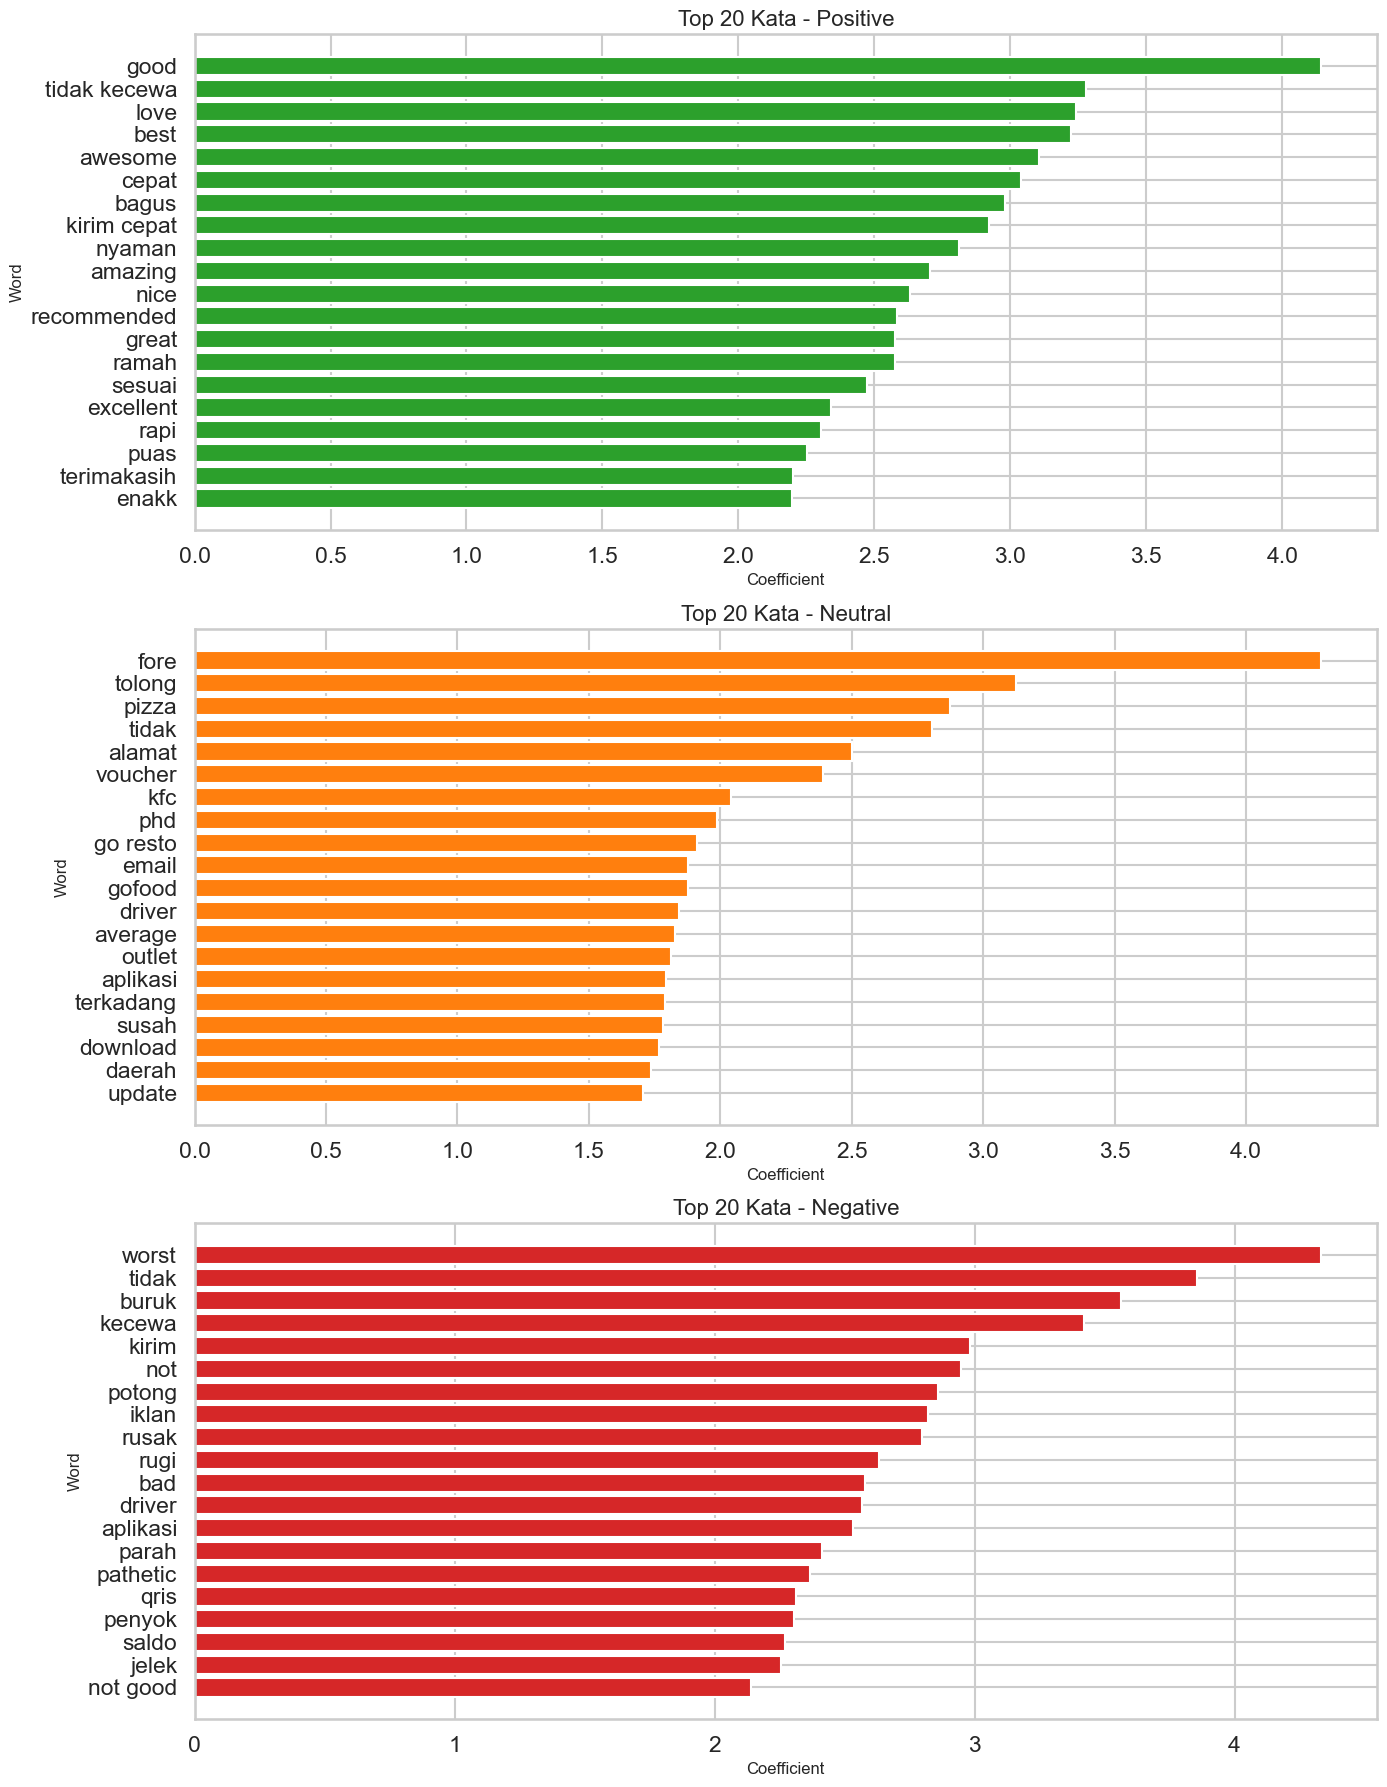

In [12]:
feature_names = np.array(final_vectorizer.get_feature_names_out())
coef = final_classifier.coef_

def resolve_class_index(class_name):
    encoded_value = label_mapping[class_name]
    return np.where(final_classifier.classes_ == encoded_value)[0][0]

explainable_tables = {}
for class_name in ['Positive', 'Neutral', 'Negative']:
    class_idx = resolve_class_index(class_name)
    class_coef = coef[class_idx]
    top_idx = np.argsort(class_coef)[-20:][::-1]
    table = pd.DataFrame({
        'feature': feature_names[top_idx],
        'coefficient': class_coef[top_idx],
    })
    explainable_tables[class_name] = table
    display(Markdown(f'### Top 20 Kata untuk Kelas {class_name}'))
    display(table)

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
colors = {'Positive': '#2ca02c', 'Neutral': '#ff7f0e', 'Negative': '#d62728'}
for ax, class_name in zip(axes, ['Positive', 'Neutral', 'Negative']):
    table = explainable_tables[class_name].sort_values('coefficient', ascending=True)
    ax.barh(table['feature'], table['coefficient'], color=colors[class_name])
    ax.set_title(f'Top 20 Kata - {class_name}')
    ax.set_xlabel('Coefficient')
    ax.set_ylabel('Word')
plt.tight_layout()
plt.show()

## SECTION 13 - Business Analysis

Analisis bisnis digunakan untuk melihat apakah model bekerja konsisten pada subset data tertentu.

Subgroup yang dianalisis:
- `Crisis_Flag`
- `Is_Sarcasm`
- `Business_Category`

Tujuannya adalah mengecek apakah ada segmentasi data yang secara sistematis lebih sulit diprediksi.

,Crisis_Flag,count,accuracy,precision_macro,recall_macro,f1_macro
0,No,7296,0.735471,0.724803,0.727142,0.725463
1,Yes,690,0.843478,0.333333,0.281159,0.305031


,Is_Sarcasm,count,accuracy,precision_macro,recall_macro,f1_macro
0,No,7936,0.745842,0.743230,0.745569,0.744030
1,Yes,50,0.580000,0.333333,0.193333,0.244726


,Business_Category,count,accuracy,precision_macro,recall_macro,f1_macro
8,Otomotif,16,1.000000,1.000000,1.000000,1.000000
11,Perlengkapan Kantor,15,0.933333,0.928571,0.944444,0.932127
1,F&B,6502,0.733313,0.735541,0.739198,0.737136
9,Perabotan,30,0.800000,0.740741,0.679221,0.683532
6,Kesehatan & Kecantikan,60,0.766667,0.679048,0.674411,0.673495
4,Ibu & Bayi,16,0.937500,0.666667,0.636364,0.650794
10,Perawatan Hewan,15,0.933333,0.629630,0.666667,0.647059
3,Hobi & Hiburan,74,0.770270,0.644444,0.644444,0.642156
5,Kerajinan & Pesta,14,0.928571,0.666667,0.600000,0.629630
0,Elektronik,90,0.700000,0.738424,0.664444,0.610969


/var/folders/l3/7nyr5mt91s39xqf3bp9dlwww0000gn/T/ipykernel_23706/701132784.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0], palette='coolwarm')
/var/folders/l3/7nyr5mt91s39xqf3bp9dlwww0000gn/T/ipykernel_23706/701132784.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[1], palette='magma')


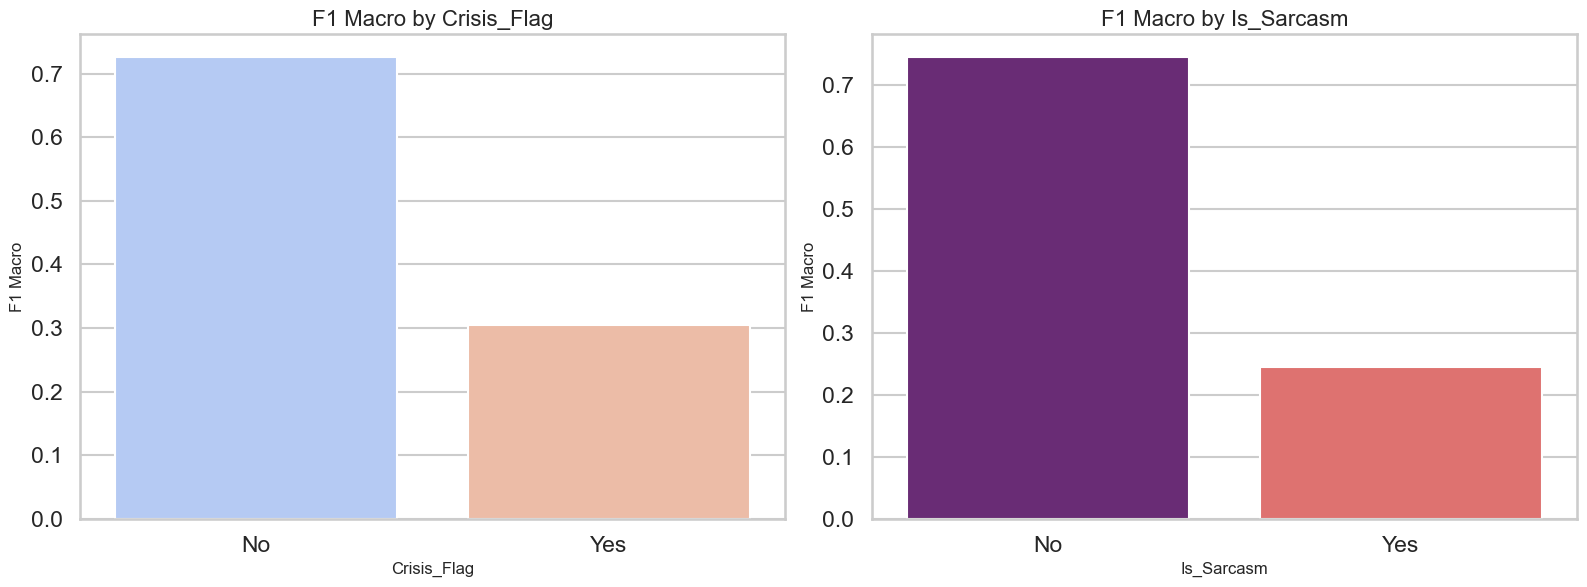

/var/folders/l3/7nyr5mt91s39xqf3bp9dlwww0000gn/T/ipykernel_23706/701132784.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=ax, palette='viridis')


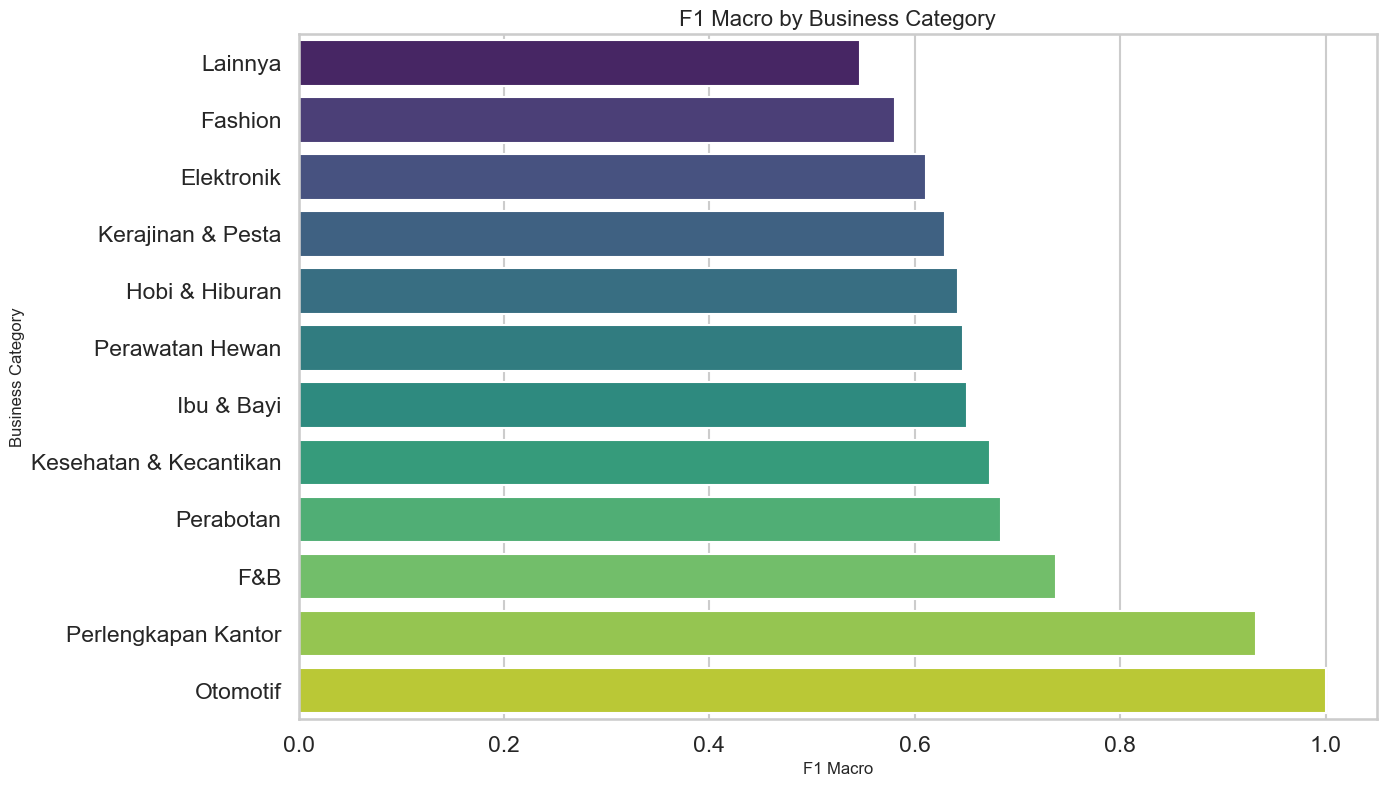

In [13]:
def subgroup_metrics(df_source, actual_array, pred_array, group_col, min_count=1):
    temp = df_source[[group_col]].copy()
    temp['Actual'] = actual_array
    temp['Predicted'] = pred_array
    rows = []
    for group_value, group_df in temp.groupby(group_col):
        if len(group_df) < min_count:
            continue
        rows.append({
            group_col: group_value,
            'count': len(group_df),
            'accuracy': accuracy_score(group_df['Actual'], group_df['Predicted']),
            'precision_macro': precision_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'recall_macro': recall_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
            'f1_macro': f1_score(group_df['Actual'], group_df['Predicted'], average='macro', zero_division=0),
        })
    return pd.DataFrame(rows).sort_values('f1_macro', ascending=False)

crisis_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Crisis_Flag')
sarcasm_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Is_Sarcasm')
category_metrics = subgroup_metrics(test_df, test_y, test_pred, 'Business_Category', min_count=10)

display(crisis_metrics)
display(sarcasm_metrics)
display(category_metrics)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=crisis_metrics, x='Crisis_Flag', y='f1_macro', ax=axes[0], palette='coolwarm')
axes[0].set_title('F1 Macro by Crisis_Flag')
axes[0].set_xlabel('Crisis_Flag')
axes[0].set_ylabel('F1 Macro')

sns.barplot(data=sarcasm_metrics, x='Is_Sarcasm', y='f1_macro', ax=axes[1], palette='magma')
axes[1].set_title('F1 Macro by Is_Sarcasm')
axes[1].set_xlabel('Is_Sarcasm')
axes[1].set_ylabel('F1 Macro')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 8))
category_plot = category_metrics.sort_values('f1_macro', ascending=True)
sns.barplot(data=category_plot, y='Business_Category', x='f1_macro', ax=ax, palette='viridis')
ax.set_title('F1 Macro by Business Category')
ax.set_xlabel('F1 Macro')
ax.set_ylabel('Business Category')
plt.tight_layout()
plt.show()

## SECTION 14 - Model Saving

Agar model dapat digunakan kembali tanpa retraining, notebook menyimpan tiga artefak utama:
- TF-IDF Vectorizer
- Label Encoder
- Logistic Regression Model

Seluruh artefak disimpan menggunakan Joblib.

In [14]:
# SAVE & VERIFY MODEL ARTIFACTS

artifacts_dir = Path("artifacts/model1")
artifacts_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save Components
joblib.dump(
    final_vectorizer,
    artifacts_dir / "tfidf_vectorizer.joblib"
)

joblib.dump(
    label_encoder,
    artifacts_dir / "label_encoder.joblib"
)

joblib.dump(
    final_classifier,
    artifacts_dir / "logistic_regression_model.joblib"
)

# Save Complete Pipeline
joblib.dump(
    final_model,
    artifacts_dir / "logistic_regression_pipeline.joblib"
)

print("=" * 60)
print("MODEL ARTIFACTS SAVED")
print("=" * 60)

for file in artifacts_dir.glob("*"):
    print(file.name)

# VERIFY SAVED PIPELINE

loaded_pipeline = joblib.load(
    artifacts_dir / "logistic_regression_pipeline.joblib"
)

sample_text = [
    "makanan enak pelayanan cepat dan memuaskan"
]

prediction = loaded_pipeline.predict(sample_text)

predicted_label = label_encoder.inverse_transform(
    prediction
)

print("\nSample Prediction:")
print(predicted_label[0])

print("\nSaved to:")
print(artifacts_dir.resolve())

MODEL ARTIFACTS SAVED
logistic_regression_pipeline.joblib
label_encoder.joblib
logistic_regression_model.joblib
tfidf_vectorizer.joblib

Sample Prediction:
Positive

Saved to:
/Users/egipsinargo/Downloads/sigap-ai/ai/artifacts/model1


## SECTION 15 - Export Result

Section ini mengekspor hasil eksperimen agar dapat dipakai langsung untuk pelaporan capstone, audit model, dan dokumentasi advisor meeting.

File yang disimpan:
- `metrics_logistic_regression.csv`
- `prediction_logistic_regression.csv`
- `classification_report_logistic_regression.csv`

In [15]:
results_dir = Path('results/model1')
results_dir.mkdir(
    parents=True,
    exist_ok=True
)

metrics_export = pd.DataFrame([
    {
        'split': 'validation',
        'accuracy': val_metrics['accuracy'],
        'precision_macro': val_metrics['precision_macro'],
        'recall_macro': val_metrics['recall_macro'],
        'f1_macro': val_metrics['f1_macro'],
    },
    {
        'split': 'test',
        'accuracy': test_metrics['accuracy'],
        'precision_macro': test_metrics['precision_macro'],
        'recall_macro': test_metrics['recall_macro'],
        'f1_macro': test_metrics['f1_macro'],
    },
])
metrics_export.to_csv(results_dir / 'metrics_logistic_regression.csv', index=False)

prediction_export = pd.concat([
    pd.DataFrame({
        'split': 'validation',
        'Review_Text_Processed': X_val.values,
        'Actual_Label': pd.Series(val_y).map(inverse_label_mapping).values,
        'Predicted_Label': pd.Series(val_pred).map(inverse_label_mapping).values,
        **{f'prob_{cls}': val_proba[:, idx] for idx, cls in enumerate(class_names)},
    }),
    pd.DataFrame({
        'split': 'test',
        'Review_Text_Processed': X_test.values,
        'Actual_Label': pd.Series(test_y).map(inverse_label_mapping).values,
        'Predicted_Label': pd.Series(test_pred).map(inverse_label_mapping).values,
        **{f'prob_{cls}': test_proba[:, idx] for idx, cls in enumerate(class_names)},
    }),
], ignore_index=True)
prediction_export.to_csv(results_dir / 'prediction_logistic_regression.csv', index=False)

def report_to_export_df(report_df, split_name):
    temp = report_df.copy()
    temp['split'] = split_name
    return temp[['split', 'label', 'precision', 'recall', 'f1-score', 'support']]

classification_report_export = pd.concat([
    report_to_export_df(val_report_df, 'validation'),
    report_to_export_df(test_report_df, 'test'),
], ignore_index=True)
classification_report_export.to_csv(results_dir / 'classification_report_logistic_regression.csv', index=False)

print('Exported files to:', results_dir.resolve())
display(metrics_export)
display(prediction_export.head())
display(classification_report_export.head())

Exported files to: /Users/egipsinargo/Downloads/sigap-ai/ai/results/model1


,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.752665,0.750373,0.753016,0.750987
1,test,0.744803,0.742288,0.744857,0.743117


,split,Review_Text_Processed,Actual_Label,Predicted_Label,prob_Negative,prob_Neutral,prob_Positive
0,validation,drmh ok packing ok kirim ok kurir ok jual ok terima kasih jual terima kasih lazada,Positive,Positive,0.279385,0.047892,0.672722
1,validation,tolong jangan rata kirim resto bentar ikut estimasi makan,Neutral,Negative,0.566266,0.387368,0.046367
2,validation,gimana aplikasi upgrade order notifikasi tidak driver grab tunggu kasi driver tunggu grab baik,Neutral,Negative,0.610307,0.386673,0.003021
3,validation,makasiiih kakak barang uda nyampeeee,Positive,Negative,0.604558,0.067144,0.328298
4,validation,bang faraz kerennnnnnn,Positive,Positive,0.226558,0.215177,0.558265


,split,label,precision,recall,f1-score,support
0,validation,Negative,0.735614,0.685671,0.709765,2666.000000
1,validation,Neutral,0.690819,0.683815,0.687299,2663.000000
2,validation,Positive,0.824684,0.889561,0.855895,2644.000000
3,validation,accuracy,0.752665,0.752665,0.752665,0.752665
4,validation,macro avg,0.750373,0.753016,0.750987,7973.000000


## SECTION 16 - Final Conclusion

Ringkasan otomatis berikut dihasilkan dari metrik validasi dan test. Bagian ini dapat langsung dipakai sebagai bahan narasi laporan capstone atau diskusi advisor meeting.

In [16]:
summary_df = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Validation_F1": [val_metrics["f1_macro"]],
    "Test_F1": [test_metrics["f1_macro"]],
    "TFIDF": [str(BEST_TFIDF_PARAMS)]
})

display(summary_df)

,Model,Validation_F1,Test_F1,TFIDF
0,Logistic Regression,0.750987,0.743117,"{'ngram_range': (1, 2), 'max_features': 20000, 'min_df': 2, 'max_df': 0.95}"


In [17]:
final_conclusion_md = f'''
### Final Conclusion

**Validation Performance**
- Accuracy: {val_metrics['accuracy']:.4f}
- Precision: {val_metrics['precision_macro']:.4f}
- Recall: {val_metrics['recall_macro']:.4f}
- F1 Score: {val_metrics['f1_macro']:.4f}

**Test Performance**
- Accuracy: {test_metrics['accuracy']:.4f}
- Precision: {test_metrics['precision_macro']:.4f}
- Recall: {test_metrics['recall_macro']:.4f}
- F1 Score: {test_metrics['f1_macro']:.4f}

**Kelebihan Model**
- Logistic Regression memberikan baseline yang stabil, cepat, dan mudah diinterpretasikan.
- TF-IDF memungkinkan model bekerja efektif pada teks sparse tanpa training yang berat.
- Koefisien model dapat digunakan untuk explainability sehingga cocok untuk laporan akademik.

**Kekurangan Model**
- Model linear kurang kuat untuk menangkap konteks yang sangat kompleks, sarcasm, dan negasi yang jauh.
- Performa sangat bergantung pada kualitas preprocessing dan representasi TF-IDF.
- Kata-kata yang ambigu atau sangat domain-spesifik masih dapat memicu salah klasifikasi.

'''

display(Markdown(final_conclusion_md))


### Final Conclusion

**Validation Performance**
- Accuracy: 0.7527
- Precision: 0.7504
- Recall: 0.7530
- F1 Score: 0.7510

**Test Performance**
- Accuracy: 0.7448
- Precision: 0.7423
- Recall: 0.7449
- F1 Score: 0.7431

**Kelebihan Model**
- Logistic Regression memberikan baseline yang stabil, cepat, dan mudah diinterpretasikan.
- TF-IDF memungkinkan model bekerja efektif pada teks sparse tanpa training yang berat.
- Koefisien model dapat digunakan untuk explainability sehingga cocok untuk laporan akademik.

**Kekurangan Model**
- Model linear kurang kuat untuk menangkap konteks yang sangat kompleks, sarcasm, dan negasi yang jauh.
- Performa sangat bergantung pada kualitas preprocessing dan representasi TF-IDF.
- Kata-kata yang ambigu atau sangat domain-spesifik masih dapat memicu salah klasifikasi.

